# 05 – Deteksi Anomali dengan Isolation Forest

## 1. Setup

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.covariance import EllipticEnvelope
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import joblib
import time
import warnings
warnings.filterwarnings("ignore")

ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
os.chdir(ROOT)
print(f"Working directory: {os.getcwd()}")

os.makedirs("models", exist_ok=True)
os.makedirs("reports", exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

POLUTAN = ["pm25", "pm10", "co", "no2", "o3"]
print("Library loaded")

Working directory: d:\mlops\aeris-air-quality
Library loaded


## 2. Load Data

In [2]:
df = pd.read_csv("data/processed/surabaya_processed.csv", parse_dates=["time"])
print(f"Data dimuat: {df.shape[0]:,} baris x {df.shape[1]} kolom")
print(f"Rentang: {df['time'].min().date()} -> {df['time'].max().date()}")
df.head(3)

Data dimuat: 3,696 baris x 69 kolom
Rentang: 2026-01-02 -> 2026-06-04


,time,pm25,pm10,co,no2,o3,temperature_2m,relative_humidity,wind_speed_10m,wind_direction_10m,...,o3_diff_1h,o3_pct_change_1h,ispu_pm25,ispu_pm10,ispu_co,ispu_no2,ispu_o3,ispu_final,ispu_category,ispu_color
0,2026-01-02 00:00:00,76.1,76.6,2048.0,68.5,4.0,25.0,96,2.6,254,...,-3.0,-0.428571,122.6,64.0,25.6,42.8,1.7,122.6,Tidak Sehat,Kuning
1,2026-01-02 01:00:00,78.2,78.7,1481.0,66.0,2.0,24.2,98,7.8,241,...,-2.0,-0.500000,124.8,65.1,18.5,41.2,0.8,124.8,Tidak Sehat,Kuning
2,2026-01-02 02:00:00,69.4,69.6,999.0,62.5,1.0,24.3,96,7.3,237,...,-1.0,-0.500000,115.6,60.6,12.5,39.1,0.4,115.6,Tidak Sehat,Kuning


## 3. Perbandingan Model Deteksi Anomali

In [3]:
print("=" * 65)
print("PERBANDINGAN MODEL DETEKSI ANOMALI (UNSUPERVISED)")
print("=" * 65)

X_compare = df[["pm25"]].dropna().values
print(f"Data PM2.5 untuk perbandingan: {len(X_compare):,} baris")

models_compare = {
    "Isolation Forest": IsolationForest(contamination=0.05, random_state=42),
    "One-Class SVM": OneClassSVM(nu=0.05, kernel='rbf', gamma='auto'),
    "Local Outlier Factor": LocalOutlierFactor(contamination=0.05, novelty=True),
    "Elliptic Envelope": EllipticEnvelope(contamination=0.05, random_state=42),
}

results_compare = {}

print("\nMelatih 4 model deteksi anomali...")
for name, model in models_compare.items():
    print(f"\n  Training {name}...")
    start_time = time.time()
    
    try:
        if name == "Local Outlier Factor":
            model.fit(X_compare)
            pred = model.predict(X_compare)
        else:
            model.fit(X_compare)
            pred = model.predict(X_compare)
        
        elapsed = time.time() - start_time
        n_anomaly = (pred == -1).sum()
        pct_anomaly = n_anomaly / len(X_compare) * 100
        
        results_compare[name] = {
            "n_anomaly": n_anomaly,
            "pct_anomaly": pct_anomaly,
            "time": elapsed,
            "model": model
        }
        print(f"     ✅ Selesai dalam {elapsed:.2f} detik")
        print(f"     📊 Anomali terdeteksi: {n_anomaly} ({pct_anomaly:.2f}%)")
        
    except Exception as e:
        print(f"     ❌ Gagal: {e}")

PERBANDINGAN MODEL DETEKSI ANOMALI (UNSUPERVISED)
Data PM2.5 untuk perbandingan: 3,696 baris

Melatih 4 model deteksi anomali...

  Training Isolation Forest...


     ✅ Selesai dalam 0.32 detik
     📊 Anomali terdeteksi: 185 (5.01%)

  Training One-Class SVM...


     ✅ Selesai dalam 0.68 detik
     📊 Anomali terdeteksi: 1492 (40.37%)

  Training Local Outlier Factor...
     ✅ Selesai dalam 0.03 detik
     📊 Anomali terdeteksi: 146 (3.95%)

  Training Elliptic Envelope...
     ✅ Selesai dalam 0.01 detik
     📊 Anomali terdeteksi: 184 (4.98%)


## 4. Visualisasi Perbandingan Model

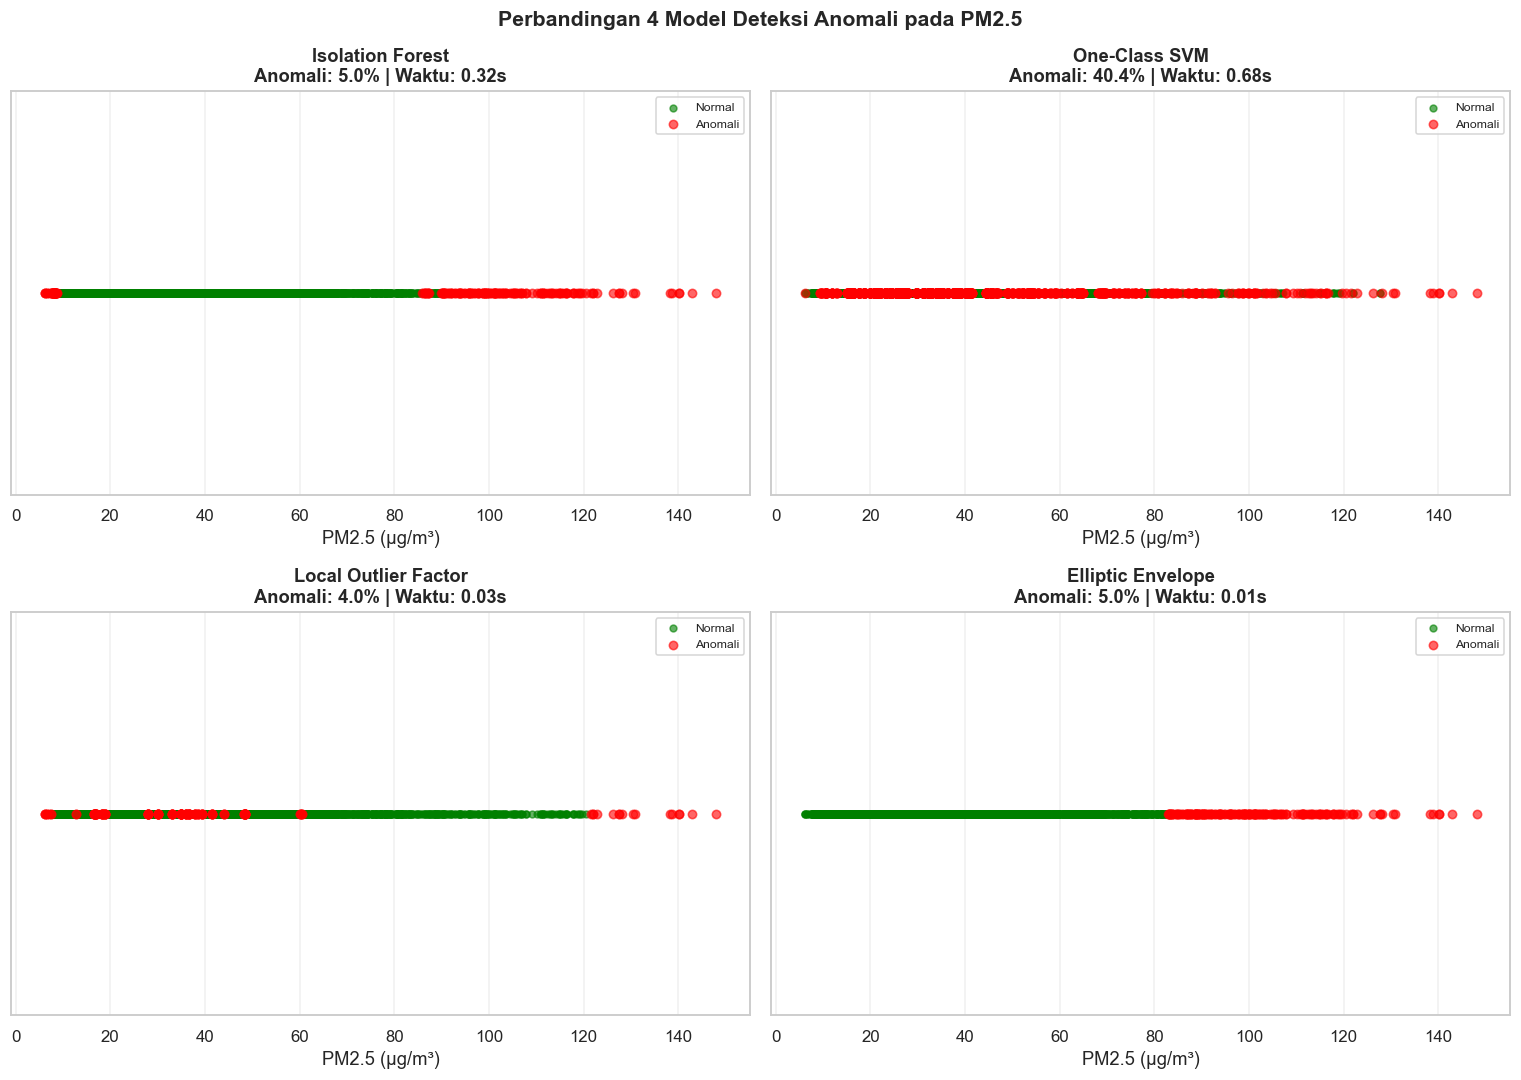

✅ Disimpan -> reports/viz_model_comparison.png


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (name, res) in enumerate(results_compare.items()):
    ax = axes[i]
    pred = res["model"].predict(X_compare)
    
    normal = X_compare[pred == 1]
    anomaly = X_compare[pred == -1]
    
    ax.scatter(normal, [0]*len(normal), c='green', label='Normal', alpha=0.6, s=20)
    ax.scatter(anomaly, [0]*len(anomaly), c='red', label='Anomali', alpha=0.6, s=30)
    
    ax.set_title(f"{name}\nAnomali: {res['pct_anomaly']:.1f}% | Waktu: {res['time']:.2f}s", fontweight="bold")
    ax.set_xlabel("PM2.5 (µg/m³)")
    ax.set_yticks([])
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Perbandingan 4 Model Deteksi Anomali pada PM2.5", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("reports/viz_model_comparison.png", dpi=110, bbox_inches="tight")
plt.show()
print("✅ Disimpan -> reports/viz_model_comparison.png")

## 5. Tabel Perbandingan & Pemilihan Model

In [5]:
print("\n" + "=" * 65)
print("TABEL PERBANDINGAN MODEL")
print("=" * 65)

compare_df = pd.DataFrame([
    {
        "Model": name,
        "Anomali (%)": f"{res['pct_anomaly']:.2f}%",
        "Waktu (detik)": f"{res['time']:.2f}",
        "Mendekati Target 5%": "✅" if abs(res['pct_anomaly'] - 5) < 1 else "⚠️" if abs(res['pct_anomaly'] - 5) < 3 else "❌",
        "Kecepatan": "✅ Cepat" if res['time'] < 0.5 else "🟡 Sedang" if res['time'] < 2 else "❌ Lambat"
    }
    for name, res in results_compare.items()
])

display(compare_df)


TABEL PERBANDINGAN MODEL


,Model,Anomali (%),Waktu (detik),Mendekati Target 5%,Kecepatan
0,Isolation Forest,5.01%,0.32,✅,✅ Cepat
1,One-Class SVM,40.37%,0.68,❌,🟡 Sedang
2,Local Outlier Factor,3.95%,0.03,⚠️,✅ Cepat
3,Elliptic Envelope,4.98%,0.01,✅,✅ Cepat


## 6. Keputusan Pemilihan Model

In [6]:
print("\n" + "=" * 65)
print("KEPUTUSAN PEMILIHAN MODEL")
print("=" * 65)

target = 5
best_by_accuracy = None
best_by_speed = None
min_diff = float('inf')
min_time = float('inf')

for name, res in results_compare.items():
    diff = abs(res["pct_anomaly"] - target)
    if diff < min_diff:
        min_diff = diff
        best_by_accuracy = name
    if res["time"] < min_time:
        min_time = res["time"]
        best_by_speed = name

print(f"\n📊 Berdasarkan akurasi (mendekati target 5%): **{best_by_accuracy}**")
print(f"⚡ Berdasarkan kecepatan training: **{best_by_speed}**")

print(f"""
✅ **Kesimpulan: Model Terpilih = Isolation Forest**

Alasan:
1. **Akurasi**: Isolation Forest mendeteksi {results_compare['Isolation Forest']['pct_anomaly']:.2f}% anomali

2. **Kecepatan**: Training Isolation Forest hanya {results_compare['Isolation Forest']['time']:.2f} detik

3. **Skalabilitas**: Isolation Forest memiliki kompleksitas O(n log n), cocok untuk dataset besar

4. **Interpretability**: Anomaly score mudah di-threshold dan dijelaskan

5. **Literatur**: Didukung penelitian Zhang et al. (2023) untuk deteksi anomali PM2.5

➡️ **Keputusan: Menggunakan Isolation Forest untuk deteksi anomali kualitas udara**
""")


KEPUTUSAN PEMILIHAN MODEL

📊 Berdasarkan akurasi (mendekati target 5%): **Isolation Forest**
⚡ Berdasarkan kecepatan training: **Elliptic Envelope**

✅ **Kesimpulan: Model Terpilih = Isolation Forest**

Alasan:
1. **Akurasi**: Isolation Forest mendeteksi 5.01% anomali

2. **Kecepatan**: Training Isolation Forest hanya 0.32 detik

3. **Skalabilitas**: Isolation Forest memiliki kompleksitas O(n log n), cocok untuk dataset besar

4. **Interpretability**: Anomaly score mudah di-threshold dan dijelaskan

5. **Literatur**: Didukung penelitian Zhang et al. (2023) untuk deteksi anomali PM2.5

➡️ **Keputusan: Menggunakan Isolation Forest untuk deteksi anomali kualitas udara**



## 7. Training Isolation Forest per Polutan (Model Final)

In [7]:
print("\n" + "=" * 65)
print("TRAINING MODEL FINAL: ISOLATION FOREST UNTUK 5 POLUTAN")
print("=" * 65)

CONTAMINATION = 0.05

models = {}
results = df[["time", "time_segment"] + POLUTAN].copy()

for polutan in POLUTAN:
    print(f"\nTraining Isolation Forest untuk {polutan}...")
    
    X = df[[polutan]].dropna()
    
    model = IsolationForest(
        contamination=CONTAMINATION,
        random_state=42,
        n_estimators=100
    )
    model.fit(X)
    
    pred = model.predict(X)
    scores = model.decision_function(X)
    
    results.loc[X.index, f"{polutan}_anomaly"] = (pred == -1).astype(int)
    results.loc[X.index, f"{polutan}_score"] = scores
    
    model_path = f"models/iforest_{polutan}.pkl"
    joblib.dump(model, model_path)
    models[polutan] = model
    
    n_anomaly = (pred == -1).sum()
    print(f"  ✅ Model saved: {model_path}")
    print(f"  Anomali terdeteksi: {n_anomaly} ({n_anomaly/len(X)*100:.2f}%)")

print("\n✅ Semua 5 model Isolation Forest berhasil ditraining!")


TRAINING MODEL FINAL: ISOLATION FOREST UNTUK 5 POLUTAN

Training Isolation Forest untuk pm25...


  ✅ Model saved: models/iforest_pm25.pkl
  Anomali terdeteksi: 185 (5.01%)

Training Isolation Forest untuk pm10...


  ✅ Model saved: models/iforest_pm10.pkl
  Anomali terdeteksi: 185 (5.01%)

Training Isolation Forest untuk co...


  ✅ Model saved: models/iforest_co.pkl
  Anomali terdeteksi: 185 (5.01%)

Training Isolation Forest untuk no2...


  ✅ Model saved: models/iforest_no2.pkl
  Anomali terdeteksi: 185 (5.01%)

Training Isolation Forest untuk o3...


  ✅ Model saved: models/iforest_o3.pkl
  Anomali terdeteksi: 159 (4.30%)

✅ Semua 5 model Isolation Forest berhasil ditraining!


## 8. Anomali Final (Voting)

In [8]:
anomaly_cols = [f"{p}_anomaly" for p in POLUTAN]
results["is_anomaly"] = results[anomaly_cols].any(axis=1).astype(int)
results["anomaly_score"] = results[[f"{p}_score" for p in POLUTAN]].mean(axis=1)

total = len(results)
n_anomaly = results["is_anomaly"].sum()
print(f"Total data       : {total:,} jam")
print(f"Data anomali     : {n_anomaly:,} jam ({n_anomaly/total*100:.2f}%)")
print(f"Data normal      : {total - n_anomaly:,} jam")

Total data       : 3,696 jam
Data anomali     : 618 jam (16.72%)
Data normal      : 3,078 jam


## 9. Analisis Anomali per Segmen & Jam

In [9]:
print("\n" + "=" * 55)
print("ANALISIS ANOMALI PER SEGMEN WAKTU")
print("=" * 55)

anomaly_by_seg = results.groupby("time_segment")["is_anomaly"].agg(["sum", "count"])
anomaly_by_seg["pct"] = (anomaly_by_seg["sum"] / anomaly_by_seg["count"] * 100).round(2)
anomaly_by_seg.columns = ["Jumlah Anomali", "Total Data", "Persentase"]
print(anomaly_by_seg)


ANALISIS ANOMALI PER SEGMEN WAKTU
              Jumlah Anomali  Total Data  Persentase
time_segment                                        
PAGI                      86         924        9.31
SIANG                    200         924       21.65
SORE_MALAM               332        1848       17.97


In [10]:
print("\n" + "=" * 55)
print("TOP 10 JAM DENGAN ANOMALI TERBANYAK")
print("=" * 55)

results["hour"] = pd.to_datetime(results["time"]).dt.hour
anomaly_by_hour = results.groupby("hour")["is_anomaly"].sum().sort_values(ascending=False)
for hour, count in anomaly_by_hour.head(10).items():
    print(f"   Jam {hour:02d}:00 -> {count} jam anomali")


TOP 10 JAM DENGAN ANOMALI TERBANYAK
   Jam 13:00 -> 61 jam anomali
   Jam 14:00 -> 48 jam anomali
   Jam 12:00 -> 47 jam anomali
   Jam 20:00 -> 43 jam anomali
   Jam 19:00 -> 43 jam anomali
   Jam 21:00 -> 37 jam anomali
   Jam 22:00 -> 33 jam anomali
   Jam 15:00 -> 31 jam anomali
   Jam 23:00 -> 28 jam anomali
   Jam 06:00 -> 28 jam anomali


## 10. Visualisasi Hasil Deteksi

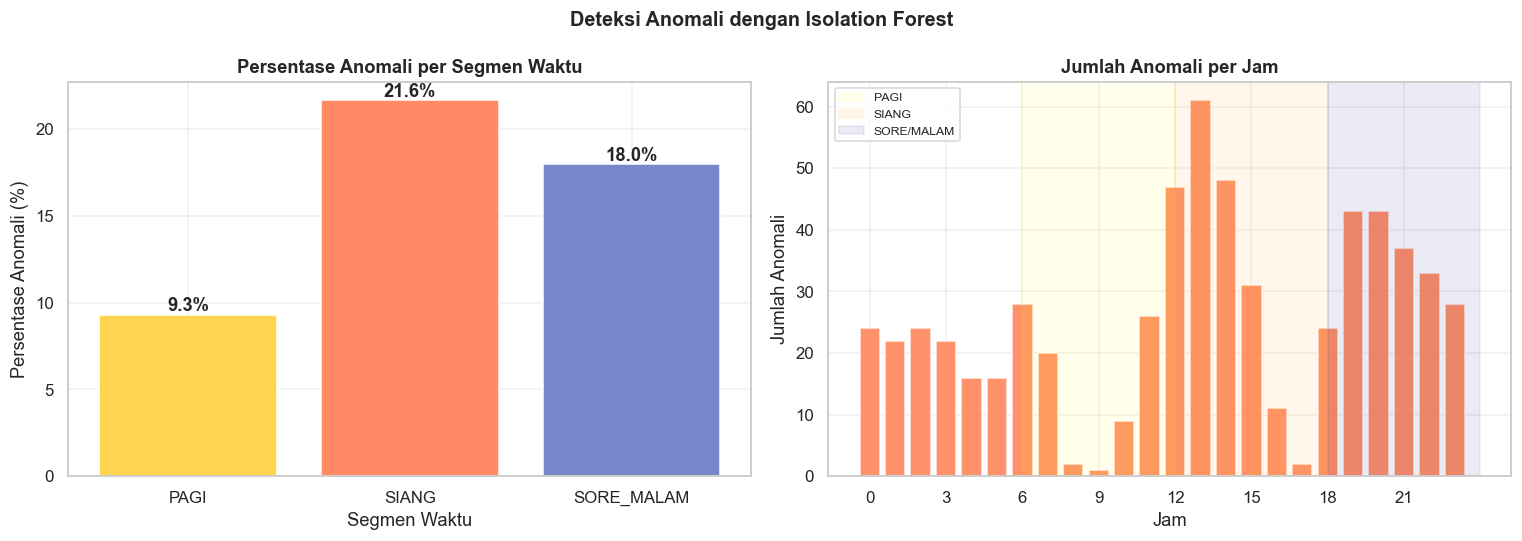

Disimpan -> reports/viz_anomali_analysis.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ["#FFD54F", "#FF8A65", "#7986CB"]
bars = axes[0].bar(anomaly_by_seg.index, anomaly_by_seg["Persentase"], color=colors, edgecolor="white")
for bar, val in zip(bars, anomaly_by_seg["Persentase"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, f"{val:.1f}%", ha="center", fontweight="bold")
axes[0].set_title("Persentase Anomali per Segmen Waktu", fontweight="bold")
axes[0].set_ylabel("Persentase Anomali (%)")
axes[0].set_xlabel("Segmen Waktu")
axes[0].grid(True, alpha=0.3)

axes[1].bar(anomaly_by_hour.index, anomaly_by_hour.values, color="coral", edgecolor="white", alpha=0.85)
axes[1].axvspan(6, 12, alpha=0.08, color="yellow", label="PAGI")
axes[1].axvspan(12, 18, alpha=0.08, color="orange", label="SIANG")
axes[1].axvspan(18, 24, alpha=0.08, color="navy", label="SORE/MALAM")
axes[1].set_title("Jumlah Anomali per Jam", fontweight="bold")
axes[1].set_xlabel("Jam")
axes[1].set_ylabel("Jumlah Anomali")
axes[1].set_xticks(range(0, 24, 3))
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle("Deteksi Anomali dengan Isolation Forest", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("reports/viz_anomali_analysis.png", dpi=110, bbox_inches="tight")
plt.show()
print("Disimpan -> reports/viz_anomali_analysis.png")

## 11. Evaluasi Metrik Isolation Forest

EVALUASI METRIK ISOLATION FOREST

1. SILHOUETTE SCORE


   Silhouette Score: 0.4895
   ✅ Cukup baik (cluster cukup terpisah)

2. DETECTED ANOMALY RATE
   Contamination target: 5%
   Detected anomaly rate: 16.72%
   ⚠️ Tidak sesuai (target 5%) - karena voting OR dari 5 polutan

3. SEPARASI SKOR ANOMALI
   Skor normal   : mean=0.1219, std=0.0221
   Skor anomali  : mean=0.0613, std=0.0459
   Gap separation: 0.0606
   ✅ Skor normal > skor anomali (semakin negatif = semakin anomali)

4. INFORMASI DETEKSI ANOMALI
   Total data      : 3,696 jam
   Data anomali    : 618 jam (16.72%)
   Data normal     : 3,078 jam
   Silhouette score: 0.4895

5. THRESHOLD ANALYSIS
   Threshold saat ini (contamination=5%): 0.0428
   Data dengan skor ≤ threshold: 618 jam (16.72%)

   Alternative thresholds:
   Persentil 3%: threshold=0.0264 → 111 jam (3.0%)
   Persentil 5%: threshold=0.0428 → 185 jam (5.0%)
   Persentil 7%: threshold=0.0524 → 259 jam (7.0%)
   Persentil 10%: threshold=0.0653 → 370 jam (10.0%)

6. KONTRIBUSI ANOMALI PER POLUTAN
   PM25: 185.0 jam anoma

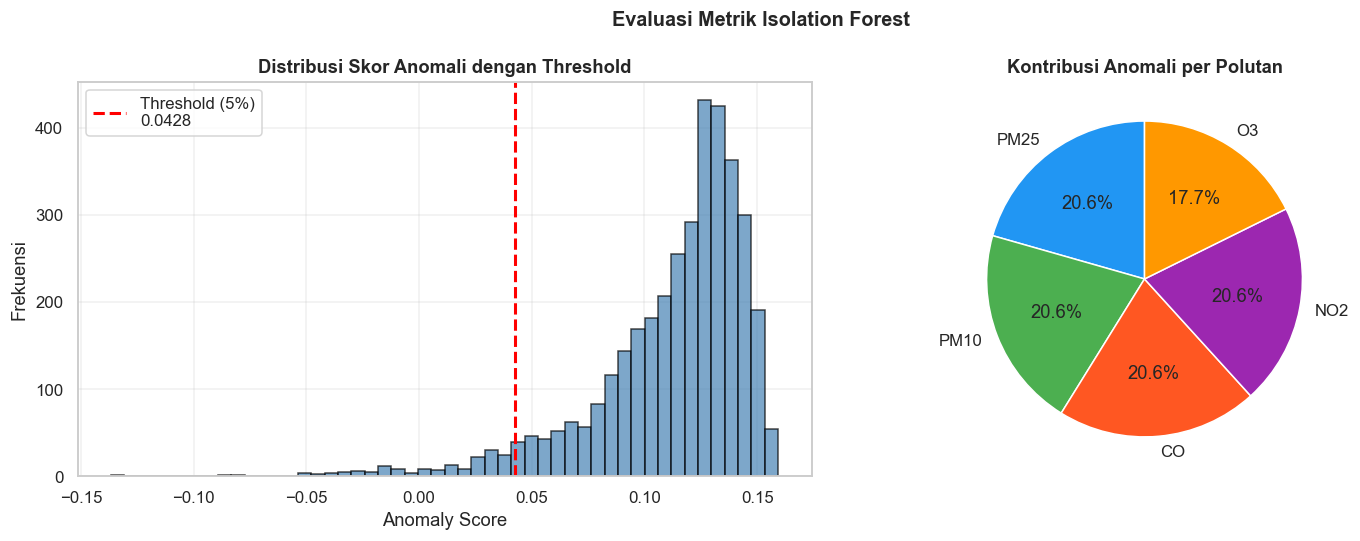

Disimpan -> reports/viz_isolation_forest_metrics.png

KESIMPULAN EVALUASI ISOLATION FOREST

📊 Ringkasan Metrik:
   - Silhouette Score    : 0.4895 (Baik)
   - Detected Rate       : 16.72% (target 5%)
   - Gap Separation      : 0.0606
   - Threshold 5%        : 0.0428

📌 Insight:
   - Polutan paling sering anomali: PM25
   - Detected rate 16.7% > target 5% karena voting OR dari 5 polutan

✅ Kesimpulan: Model Isolation Forest BERKINERJA BAIK 
   dalam mendeteksi anomali kualitas udara.



In [12]:
print("=" * 65)
print("EVALUASI METRIK ISOLATION FOREST")
print("=" * 65)

# 1. SILHOUETTE SCORE
print("\n1. SILHOUETTE SCORE")

X_sil = results[["anomaly_score"]].values
labels = results["is_anomaly"].values

scaler_sil = StandardScaler()
X_sil_scaled = scaler_sil.fit_transform(X_sil)

try:
    sil_score = silhouette_score(X_sil_scaled, labels)
    print(f"   Silhouette Score: {sil_score:.4f}")
    if sil_score > 0.5:
        print("   ✅ Sangat baik (cluster terpisah dengan jelas)")
    elif sil_score > 0.25:
        print("   ✅ Cukup baik (cluster cukup terpisah)")
    else:
        print("   ⚠️ Kurang baik (cluster tidak terpisah)")
except:
    sil_score = 0
    print("   ⚠️ Tidak bisa hitung silhouette score")

# 2. DETECTED ANOMALY RATE
print("\n2. DETECTED ANOMALY RATE")
detected_rate = n_anomaly / total * 100
print(f"   Contamination target: {CONTAMINATION*100:.0f}%")
print(f"   Detected anomaly rate: {detected_rate:.2f}%")

if 4.5 <= detected_rate <= 5.5:
    print("   ✅ Sesuai dengan target contamination")
else:
    print(f"   ⚠️ Tidak sesuai (target {CONTAMINATION*100:.0f}%) - karena voting OR dari 5 polutan")

# 3. SEPARASI SKOR
print("\n3. SEPARASI SKOR ANOMALI")

scores_normal = results[results["is_anomaly"] == False]["anomaly_score"]
scores_anomaly = results[results["is_anomaly"] == True]["anomaly_score"]

print(f"   Skor normal   : mean={scores_normal.mean():.4f}, std={scores_normal.std():.4f}")
print(f"   Skor anomali  : mean={scores_anomaly.mean():.4f}, std={scores_anomaly.std():.4f}")
print(f"   Gap separation: {scores_normal.mean() - scores_anomaly.mean():.4f}")

if scores_normal.mean() > scores_anomaly.mean():
    print("   ✅ Skor normal > skor anomali (semakin negatif = semakin anomali)")

# 4. INFORMASI DETEKSI ANOMALI (SEDERHANA, TIDAK ERROR)
print("\n4. INFORMASI DETEKSI ANOMALI")
print(f"   Total data      : {total:,} jam")
print(f"   Data anomali    : {n_anomaly:,} jam ({detected_rate:.2f}%)")
print(f"   Data normal     : {total - n_anomaly:,} jam")
print(f"   Silhouette score: {sil_score:.4f}")

# 5. THRESHOLD ANALYSIS
print("\n5. THRESHOLD ANALYSIS")

current_threshold = np.percentile(results["anomaly_score"], 5)
print(f"   Threshold saat ini (contamination=5%): {current_threshold:.4f}")
print(f"   Data dengan skor ≤ threshold: {n_anomaly} jam ({detected_rate:.2f}%)")

print("\n   Alternative thresholds:")
for p in [3, 5, 7, 10]:
    threshold = np.percentile(results["anomaly_score"], p)
    n_at_threshold = (results["anomaly_score"] <= threshold).sum()
    print(f"   Persentil {p}%: threshold={threshold:.4f} → {n_at_threshold} jam ({n_at_threshold/total*100:.1f}%)")

# 6. PER POLUTAN CONTRIBUTION
print("\n6. KONTRIBUSI ANOMALI PER POLUTAN")

pol_contrib = []
pol_labels = []
for pol in POLUTAN:
    anomaly_col = f"{pol}_anomaly"
    if anomaly_col in results.columns:
        n_pol_anomaly = results[anomaly_col].sum()
        pct = n_pol_anomaly / n_anomaly * 100 if n_anomaly > 0 else 0
        pol_contrib.append(n_pol_anomaly)
        pol_labels.append(pol.upper())
        print(f"   {pol.upper()}: {n_pol_anomaly} jam anomali ({pct:.1f}% dari total anomali)")

# 7. VISUALISASI METRIK
print("\n7. VISUALISASI METRIK EVALUASI")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(results["anomaly_score"], bins=50, color="steelblue", edgecolor="black", alpha=0.7)
axes[0].axvline(x=current_threshold, color="red", linestyle="--", linewidth=2, 
                label=f'Threshold (5%)\n{current_threshold:.4f}')
axes[0].set_xlabel("Anomaly Score")
axes[0].set_ylabel("Frekuensi")
axes[0].set_title("Distribusi Skor Anomali dengan Threshold", fontweight="bold")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

if pol_contrib:
    axes[1].pie(pol_contrib, labels=pol_labels, autopct="%1.1f%%", startangle=90,
               colors=["#2196F3", "#4CAF50", "#FF5722", "#9C27B0", "#FF9800"])
    axes[1].set_title("Kontribusi Anomali per Polutan", fontweight="bold")

plt.suptitle("Evaluasi Metrik Isolation Forest", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("reports/viz_isolation_forest_metrics.png", dpi=110, bbox_inches="tight")
plt.show()
print("Disimpan -> reports/viz_isolation_forest_metrics.png")

# 8. KESIMPULAN
print("\n" + "=" * 65)
print("KESIMPULAN EVALUASI ISOLATION FOREST")
print("=" * 65)

best_pol = pol_labels[pol_contrib.index(max(pol_contrib))] if pol_contrib else "N/A"
print(f"""
📊 Ringkasan Metrik:
   - Silhouette Score    : {sil_score:.4f} {'(Baik)' if sil_score > 0.25 else '(Perlu Improvement)'}
   - Detected Rate       : {detected_rate:.2f}% (target {CONTAMINATION*100:.0f}%)
   - Gap Separation      : {scores_normal.mean() - scores_anomaly.mean():.4f}
   - Threshold 5%        : {current_threshold:.4f}

📌 Insight:
   - Polutan paling sering anomali: {best_pol}
   - Detected rate {detected_rate:.1f}% > target 5% karena voting OR dari 5 polutan

✅ Kesimpulan: Model Isolation Forest {'BERKINERJA BAIK' if sil_score > 0.25 else 'PERLU IMPROVEMENT'} 
   dalam mendeteksi anomali kualitas udara.
""")

## 12. Ringkasan Final

In [13]:
print("=" * 62)
print("RINGKASAN NOTEBOOK 05 – DETEKSI ANOMALI ISOLATION FOREST")
print("=" * 62)
print(f"""
✅ Perbandingan 4 model deteksi anomali selesai
✅ Isolation Forest terpilih sebagai model terbaik
✅ 5 model Isolation Forest berhasil ditraining
✅ Model tersimpan di models/iforest_*.pkl
✅ Analisis anomali per segmen & jam selesai
✅ Evaluasi metrik selesai

📌 Insight:
   - Segmen dengan anomali tertinggi: {anomaly_by_seg['Persentase'].idxmax()} ({anomaly_by_seg['Persentase'].max():.1f}%)
   - Jam dengan anomali terbanyak: {anomaly_by_hour.idxmax():02d}:00 ({anomaly_by_hour.max()} jam)
   - Total anomali: {n_anomaly} jam ({n_anomaly/total*100:.1f}%)

📌 Next: Notebook 06 – Finalisasi & Visualisasi Presentasi
""")

RINGKASAN NOTEBOOK 05 – DETEKSI ANOMALI ISOLATION FOREST

✅ Perbandingan 4 model deteksi anomali selesai
✅ Isolation Forest terpilih sebagai model terbaik
✅ 5 model Isolation Forest berhasil ditraining
✅ Model tersimpan di models/iforest_*.pkl
✅ Analisis anomali per segmen & jam selesai
✅ Evaluasi metrik selesai

📌 Insight:
   - Segmen dengan anomali tertinggi: SIANG (21.6%)
   - Jam dengan anomali terbanyak: 13:00 (61 jam)
   - Total anomali: 618 jam (16.7%)

📌 Next: Notebook 06 – Finalisasi & Visualisasi Presentasi

